# Topics Comparison

Notebook for comparing `S3`, `FASTopic`, and a `TF-IDF` baseline on canonical Polymarket markets. The default text view is `full_description`, but every detector also supports `question` and `question_plus_full_description`.

In [1]:
from polymarket_research.data.canonical import CanonicalDatasetBuilder
from polymarket_research.data.raw import RawExternalCovariates, RawPolymarketHandle
from polymarket_research.utils import setup_root

from polymarket_research.research.topic_models import (
    FASTopicFactory,
    S3TopicFactory,
    TFIDFTopicFactory,
    build_topic_input_frame,
    compare_topic_factories,
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)
pd.set_option('display.max_colwidth', None)
%matplotlib inline


/Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/_snmf.py:19: UserWarning: JAX not found, continuing with NumPy implementation.
  warnings.warn("JAX not found, continuing with NumPy implementation.")


In [2]:
REPO_ROOT = setup_root()
CANONICAL_CACHE_DIR = REPO_ROOT / "research_notebooks" / "running_artefacts_new" / "canonical_dataset"
MARKET_LIMIT = None
MARKET_ORDER = None  # one of: None, "latest", "largest"

if (CANONICAL_CACHE_DIR / "markets.parquet").exists() and MARKET_LIMIT is None and MARKET_ORDER is None:
    from polymarket_research.data.canonical import CanonicalDataset
    canonical = CanonicalDataset.from_parquet(CANONICAL_CACHE_DIR)
    print("Loaded canonical from parquet cache:", CANONICAL_CACHE_DIR)
else:
    raw_handle = RawPolymarketHandle()
    raw_bundle = raw_handle.load_bundle(
        include_market_universe=False,
        include_download_manifest=False,
        include_probabilities=True,
        include_raw_trades=False,
        market_limit=MARKET_LIMIT,
        market_order=MARKET_ORDER,
    )
    raw_external = RawExternalCovariates().load()
    canonical = CanonicalDatasetBuilder(
        raw_dataset=raw_bundle,
        raw_external=raw_external,
        resolved_only=True,
    ).build()
    if MARKET_LIMIT is None and MARKET_ORDER is None:
        canonical.save(CANONICAL_CACHE_DIR)
    print("Built canonical from SQLite")

all_markets = canonical.markets.copy()
probabilities = canonical.probabilities.copy()
print(f"Canonical resolved markets: {len(all_markets)}")
print("Market limit:", MARKET_LIMIT)
print("Market order:", MARKET_ORDER)
display(all_markets[["market_id", "question", "domain", "family_id", "volume_num"]].head(5))


Loaded canonical from parquet cache: /Users/sneddy/research/polymarket_research/research_notebooks/running_artefacts_new/canonical_dataset
Canonical resolved markets: 15662
Market limit: None
Market order: None


,market_id,question,domain,family_id,volume_num
0,1914442,"Will Hegseth say ""AI"" or ""Cyber"" during press conference?",unassigned,unassigned::::hegseth say ai or cyber during,38222.744674
1,1912772,"Trump announces US x Iran ceasefire end by April 8, 2026?",unassigned,unassigned::::trump announces us x iran ceasefire,38220.348645
2,1908626,Trump announces Hormuz deadline extension today?,unassigned,unassigned::::trump announces hormuz deadline extension today,987122.280619
3,1891746,"Will Trump say ""Strait"" or ""Hormuz"" during events with Rutte?",unassigned,unassigned::::trump say strait or hormuz during,27053.816874
4,1882888,Will Trump's remarks not air?,unassigned,unassigned::::trump s remarks not air,33098.189315


In [3]:
topic_markets = build_topic_input_frame(all_markets)
topic_markets["question_len"] = topic_markets["question"].fillna("").str.len()
topic_markets["full_description_len"] = topic_markets["full_description"].fillna("").str.len()

coverage = pd.DataFrame({
    "n_rows": [len(topic_markets)],
    "nonempty_question": [int(topic_markets["question"].fillna("").str.strip().ne("").sum())],
    "nonempty_full_description": [int(topic_markets["full_description"].fillna("").str.strip().ne("").sum())],
    "mean_question_len": [float(topic_markets["question_len"].mean())],
    "mean_full_description_len": [float(topic_markets["full_description_len"].mean())],
})
display(coverage)
display(topic_markets[["market_id", "question", "full_description", "volume_num"]].sample(2))

,n_rows,nonempty_question,nonempty_full_description,mean_question_len,mean_full_description_len
0,15662,15662,15662,57.048206,925.017558


,market_id,question,full_description,volume_num
7796,591854,Will Israel strike Syria by September 30?,"This market will resolve to ""Yes"" if Israel initiates a drone, missile, or air strike on Syrian soil or any Syrian embassy or consulate between September 9, 3 PM ET, and September 30, 2025, 11:59 PM ET. Otherwise, this market will resolve to ""No"". For the purposes of this market, a qualifying ""strike"" is defined as the use of aerial bombs, drones or missiles (including cruise or ballistic missiles) launched by Israeli military forces that impact Syrian ground territory or any official Syrian embassy or consulate (e.g., if a weapons depot on Syrian soil is hit by an Israeli missile, this market will resolve to ""Yes"") that is officially acknowledged by the Israeli government or a consensus of credible reporting. Missiles or drones which are intercepted and surface-to-air missile strikes will not be sufficient for a ""Yes"" resolution regardless of whether they land on Syrian territory or cause damage. Actions such as artillery fire, small arms fire, FPV or ATGM strikes directly, ground incursions, naval shelling, cyberattacks, or other operations conducted by Israeli ground operatives will not qualify. The resolution source will be a consensus of credible reporting. Will Israel strike Syria by...?",76279.059893
9399,561789,OpenAI browser in July?,"This market will resolve to ""Yes"" if OpenAI publicly releases a standalone web browser that is intended for general web browsing and is available for use by the public in at least one country or region by July 31, 2025, 11:59 PM ET. Otherwise, this market will resolve to ""No"". For this market to resolve to ""Yes,"" such a browser must be launched and publicly accessible, including via open beta or open rolling free waitlist signups. A closed beta or any form of private access will not suffice. The release must be clearly defined and publicly announced by OpenAI as being accessible to the general public. Browser extensions, plugins, or integrations within third-party browsers do not count; it must be a standalone browser application. The primary resolution source will be official announcements from OpenAI. If there is ambiguity, a consensus of credible reporting will be used. OpenAI browser in July?",100165.580510


## Run Config

Use `TEXT_MODE = "full_description"` for the description-centric view. Switch to `"question"` or `"question_plus_full_description"` to compare text views.

In [4]:
TEXT_MODE = "full_description"
N_TOPICS = 10
MIN_DF = 5
MAX_DF = 0.5
TOP_TERMS = 8
FASTOPIC_EPOCHS = 60
SAMPLE_SIZE = None
SORT_BY = "volume_num"
REDUCERS = ["umap", "tsne"]

work_markets = topic_markets.copy()
work_markets = work_markets.loc[work_markets[TEXT_MODE].fillna("").astype(str).str.strip().ne("")].copy()
if SORT_BY in work_markets.columns:
    work_markets = work_markets.sort_values(SORT_BY, ascending=False, kind="stable")
if SAMPLE_SIZE is not None:
    work_markets = work_markets.head(int(SAMPLE_SIZE)).copy()

print("Rows used for modeling:", len(work_markets))
display(work_markets[["market_id", "question", "full_description", "volume_num"]].sample(2))

Rows used for modeling: 15662


,market_id,question,full_description,volume_num
14746,520456,Will Saquon Barkley score the first touchdown of Super Bowl LIX?,"This market will resolve according to the player/unit to score the first touchdown of Super Bowl LIX. Any rushing or receiving touchdowns will count. Passing touchdowns will not qualify. Special teams and defensive touchdowns will count for the listed D/ST unit, not the individual player who scores them. If this game is delayed or postponed past February 28, 2025, 11:59 PM ET, this market will resolve to “No TD”. The resolution source for this market will be the official broadcast Super Bowl LIX on Fox, however a consensus of credible repotting may also be used. First Touchdown Scorer?",38860.297387
12983,530430,Will Oscar Piastri win the 2025 Japanese Grand Prix?,"This market will resolve according to the winner of the 2025 Japan Grand Prix scheduled for April 6, 2025. If the 2025 Japanese Grand Prix is canceled or rescheduled to a date after April 28, 2025, this market will resolve to “Other.” The resolution source will be the official Formula 1 website and credible sports news reporting. Japan Grand Prix Winner",50985.489452


In [5]:
topic_factories = [
    S3TopicFactory(
        n_topics=N_TOPICS,
        text_mode=TEXT_MODE,
        min_df=MIN_DF,
        max_df=MAX_DF,
        top_terms=TOP_TERMS,
    ),
    FASTopicFactory(
        n_topics=N_TOPICS,
        text_mode=TEXT_MODE,
        min_df=MIN_DF,
        max_df=MAX_DF,
        top_terms=TOP_TERMS,
        n_epochs=FASTOPIC_EPOCHS,
    ),
    TFIDFTopicFactory(
        n_topics=N_TOPICS,
        text_mode=TEXT_MODE,
        min_df=MIN_DF,
        max_df=MAX_DF,
        top_terms=TOP_TERMS,
    ),
]

results, comparison_summary = compare_topic_factories(work_markets, topic_factories)
display(comparison_summary)

Output()

[18:51:29] Documents encoded.                                                                         ]8;id=869316;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/decomp.py\decomp.py]8;;\:]8;id=307863;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/decomp.py#144\144]8;;\

/Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/sklearn/decomposition/_fastica.py:132: 
ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(

           Decomposition done.                                                                        ]8;id=268767;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/decomp.py\decomp.py]8;;\:]8;id=785102;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/decomp.py#151\151]8;;\

[18:51:30] Term extraction done.                                                                      ]8;id=524684;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/decomp.py\decomp.py]8;;\:]8;id=336750;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/decomp.py#154\154]8;;\

...

           Model fitting done.                                                                        ]8;id=225833;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/decomp.py\decomp.py]8;;\:]8;id=793546;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/decomp.py#184\184]8;;\

Output()

[18:53:35] Term extraction done.                                                                    ]8;id=66544;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/fastopic.py\fastopic.py]8;;\:]8;id=775735;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/fastopic.py#161\161]8;;\

[18:53:51] Model fitting done.                                                                      ]8;id=294130;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/fastopic.py\fastopic.py]8;;\:]8;id=670756;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/fastopic.py#164\164]8;;\

,model_name,text_mode,n_documents,n_topics,runtime_seconds,mean_topic_confidence
0,TFIDF,full_description,15662,10,1.162174,0.136005
1,S3,full_description,15662,10,129.425886,0.531154
2,FASTopic,full_description,15662,10,132.156960,0.257644


In [6]:
for model_name, result in results.items():
    print("=" * 100)
    print(model_name)
    display(result.topic_summary()[["topic_id", "topic_label", "topic_size"]])

S3


,topic_id,topic_label,topic_size
0,4,"topic_4: credible sports, super bowl, nfl, information nfl",2288
1,7,"topic_7: harris, kamala harris, white house, deputies",2116
2,5,"topic_5: lyft earnings, market binance, quarterly earnings, earnings gaap",2077
3,0,"topic_0: israel strikes, israel strike, strike gaza, strike lebanon",1631
4,1,"topic_1: top10 netflix, list top10, ranks netflix, list 2025",1621
5,8,"topic_8: domestically opening, opening weekend, gross domestically, movie numbers",1423
6,6,"topic_6: academy awards, oscars best, awards nominations, www oscars",1249
7,3,"topic_3: 2025 canadian, 2025 gross, march 2025, 2025 state",1136
8,2,"topic_2: earnings release, does release, com confirmed, scheduled release",1062
9,9,"topic_9: context joyful, pluralization, words count, possessive term",1059


FASTopic


,topic_id,topic_label,topic_size
0,6,"topic_6: tournament, player, academy, declared",2247
1,5,"topic_5: election, round, vote, votes",2194
2,8,"topic_8: data, weekend, gaap eps, gaap",1797
3,3,"topic_3: pope, senate, listed individual, bulletin",1680
4,7,"topic_7: trading, cup, fifa, price",1665
5,4,"topic_4: publicly announced, form, specific, imports",1458
6,9,"topic_9: israel, iranian, israeli, iran",1244
7,1,"topic_1: term, compound word, compound, listed term",1172
8,2,"topic_2: deepstatemap, location, red, isw map",1150
9,0,"topic_0: highest arena, checked, bowl lx, source unavailable",1055


TFIDF


,topic_id,topic_label,topic_size
0,0,"topic_0: trump, 31, et market, 2025 11",7394
1,7,"topic_7: winner, 2026, tournament, academy",2811
2,4,"topic_4: election, party, round, based",1456
3,2,"topic_2: count, term, event, trump",966
4,5,"topic_5: strike, missiles, ground, missile",834
5,9,"topic_9: game, fifa, isw, cup",705
6,1,"topic_1: weekend, box office, box, office",583
7,8,"topic_8: leaderboard, arena, ai, arena score",569
8,3,"topic_3: eps, gaap, gaap eps, earnings",211
9,6,"topic_6: approval, rating, approval rating, silver bulletin",133


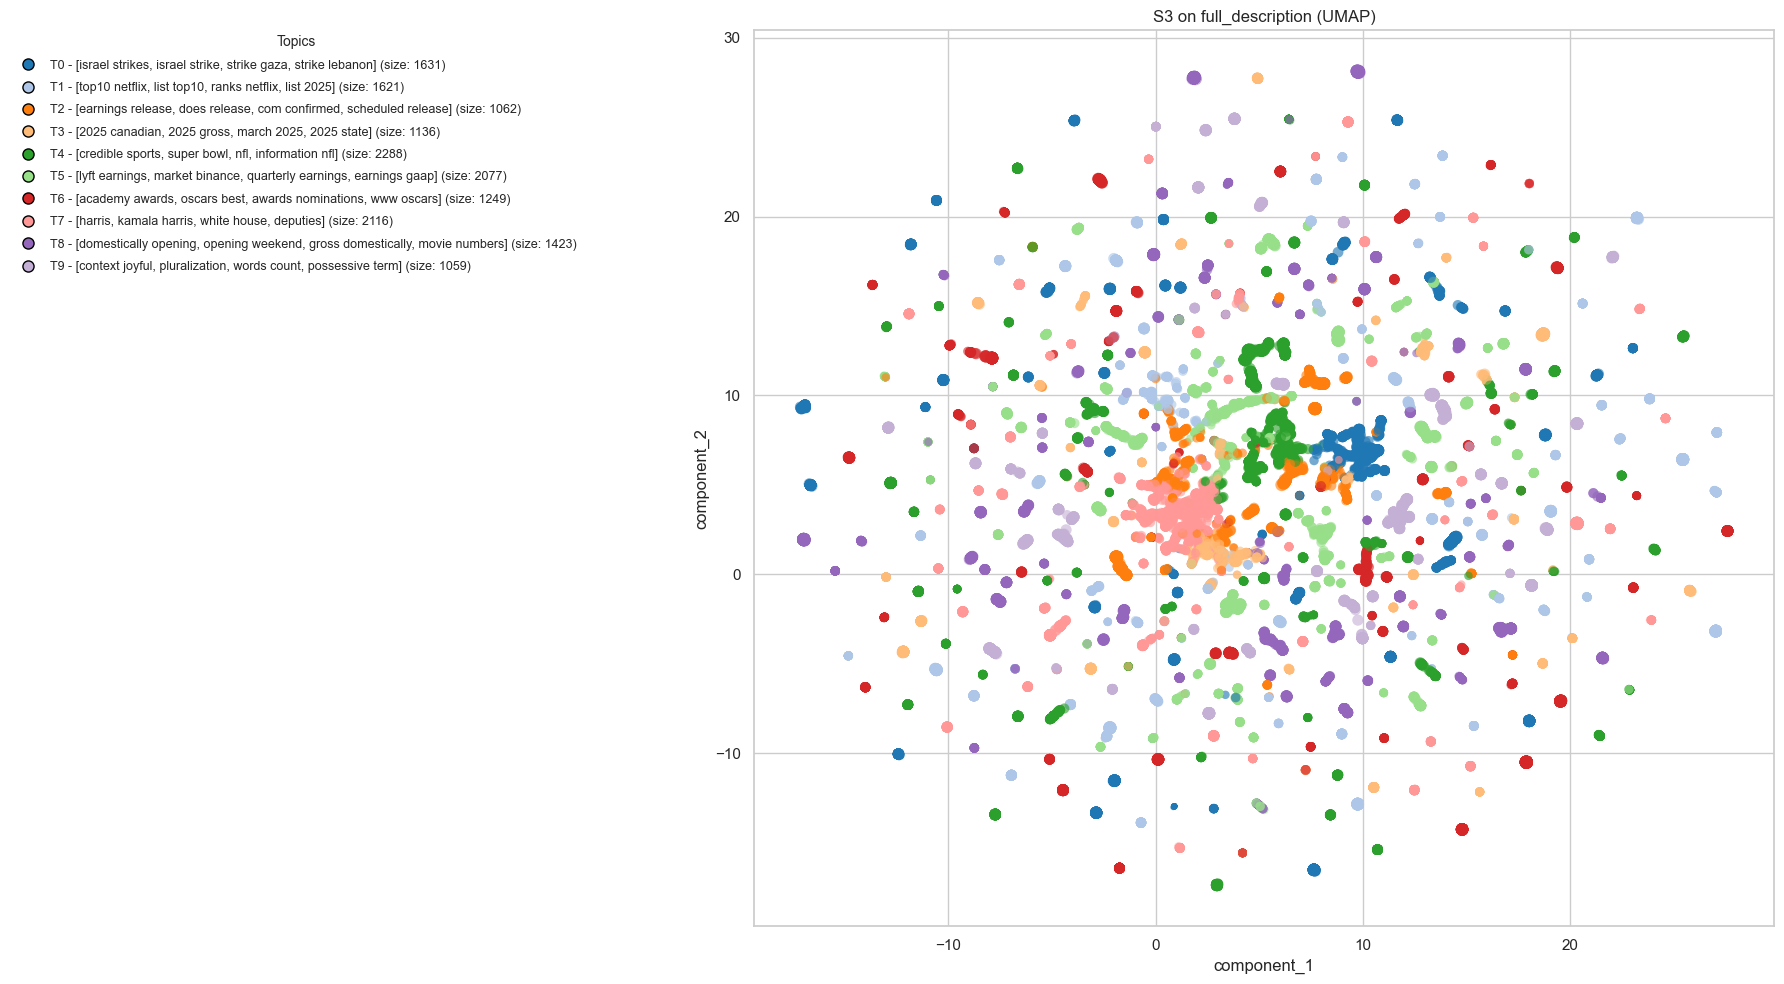

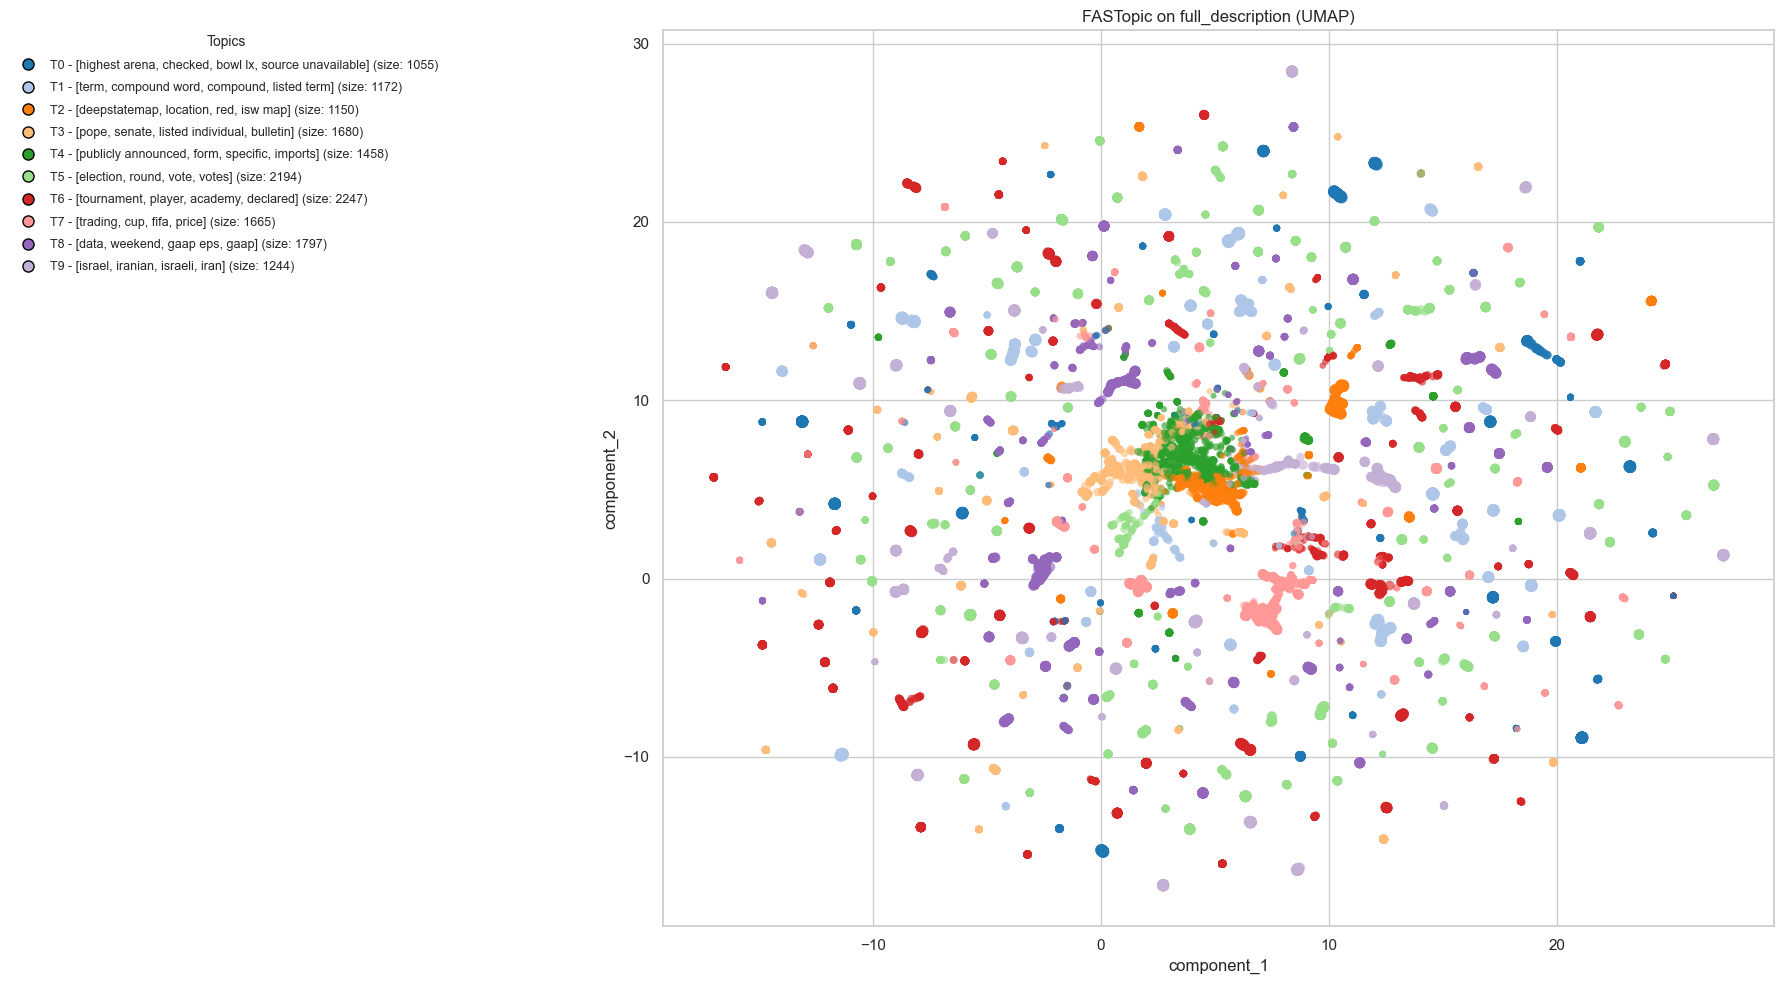

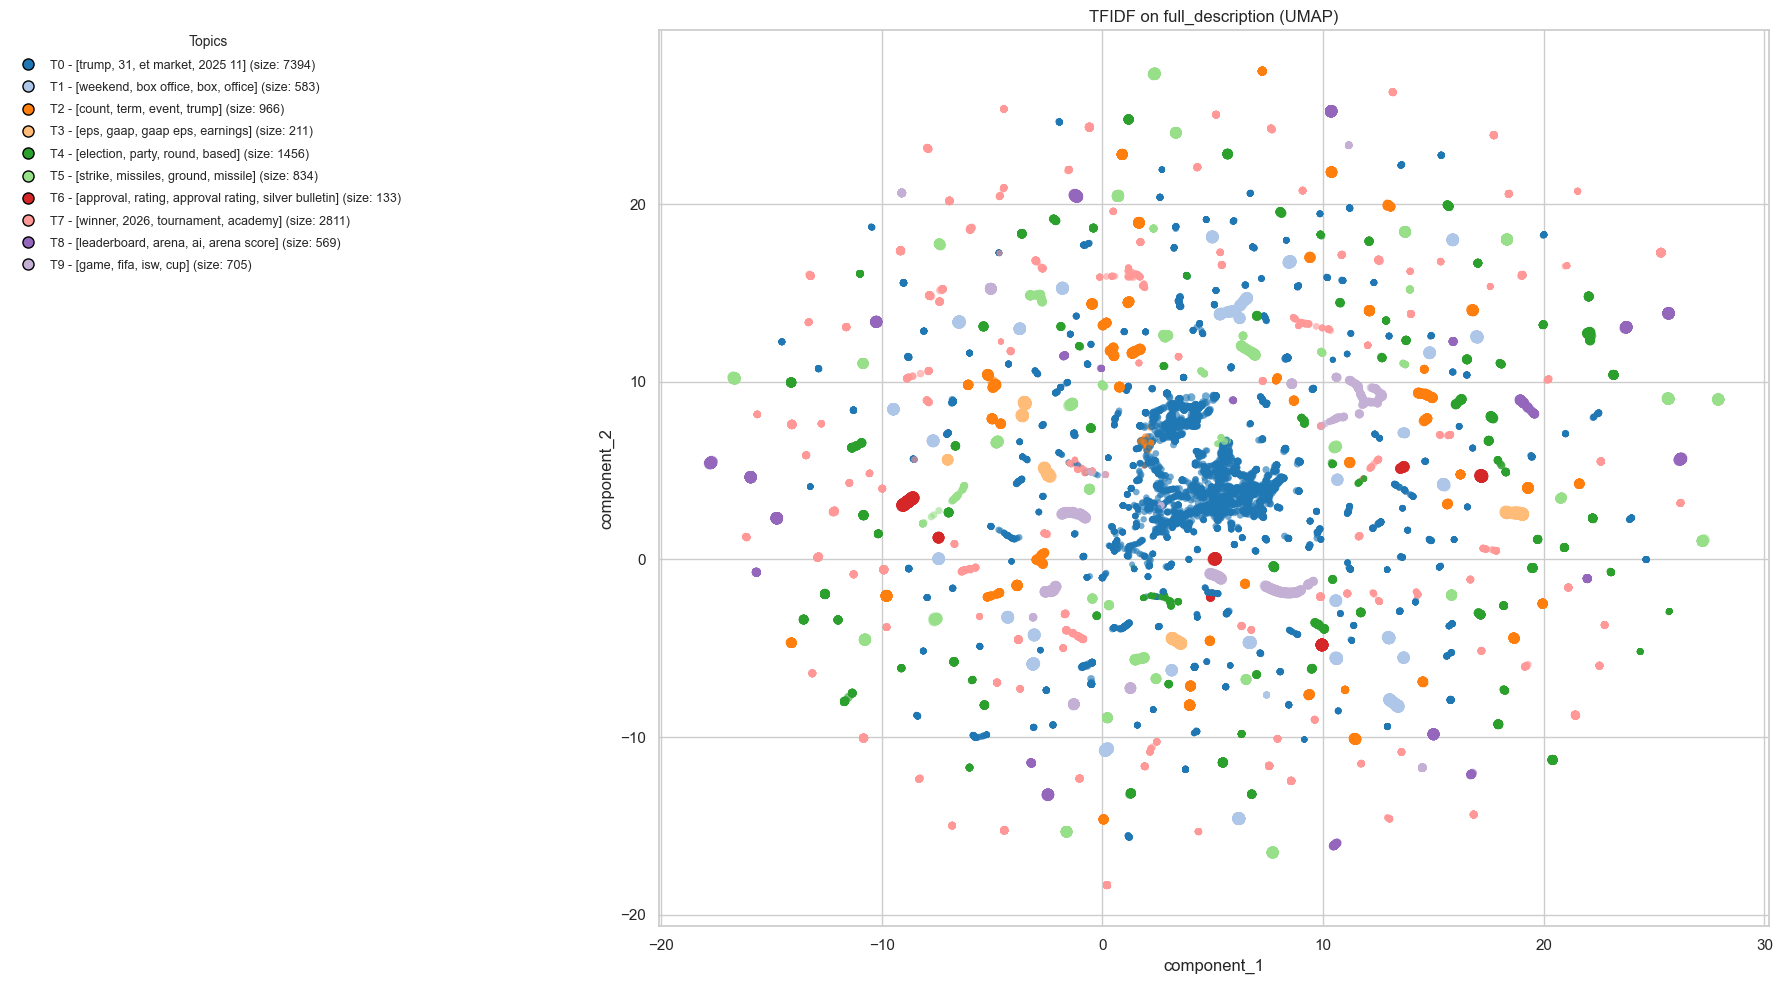

In [7]:
for model_name, result in results.items():
    fig, axes, projected = result.plot_2d_with_topic_map(
        reducer="umap",
        random_state=0,
        legend_mode="full",
        show_table=False,
        figsize=(18, 10),
    )
    plt.show()

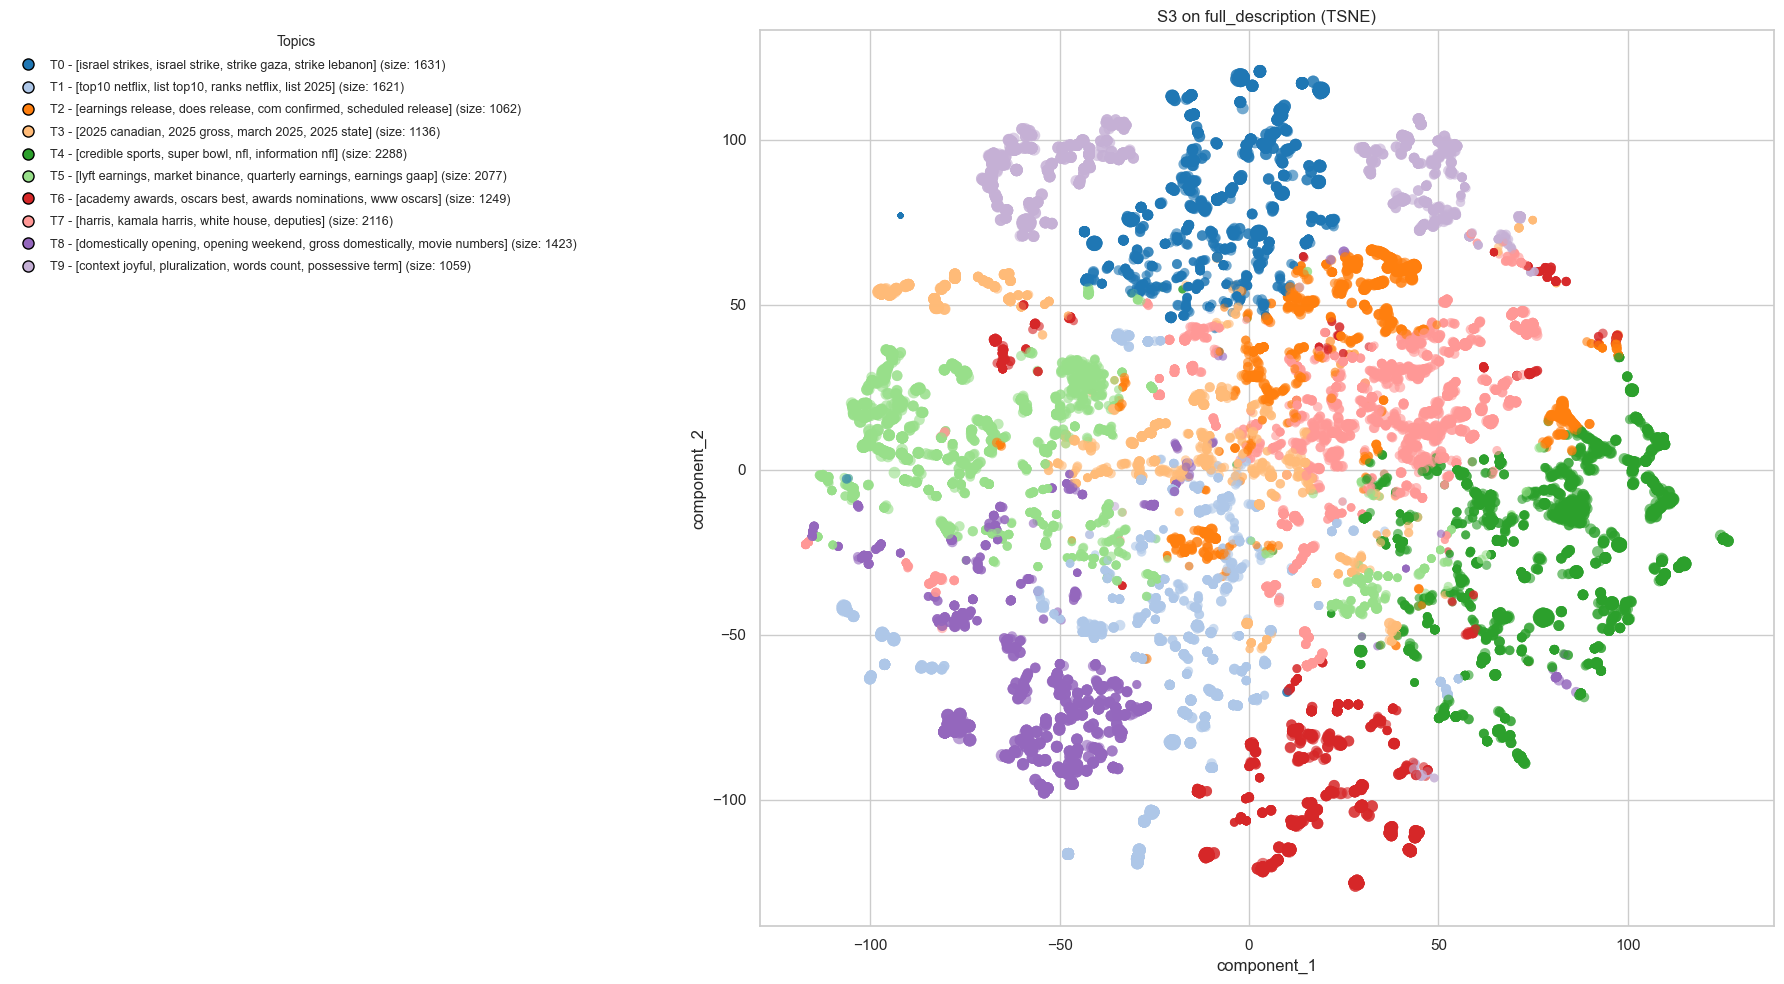

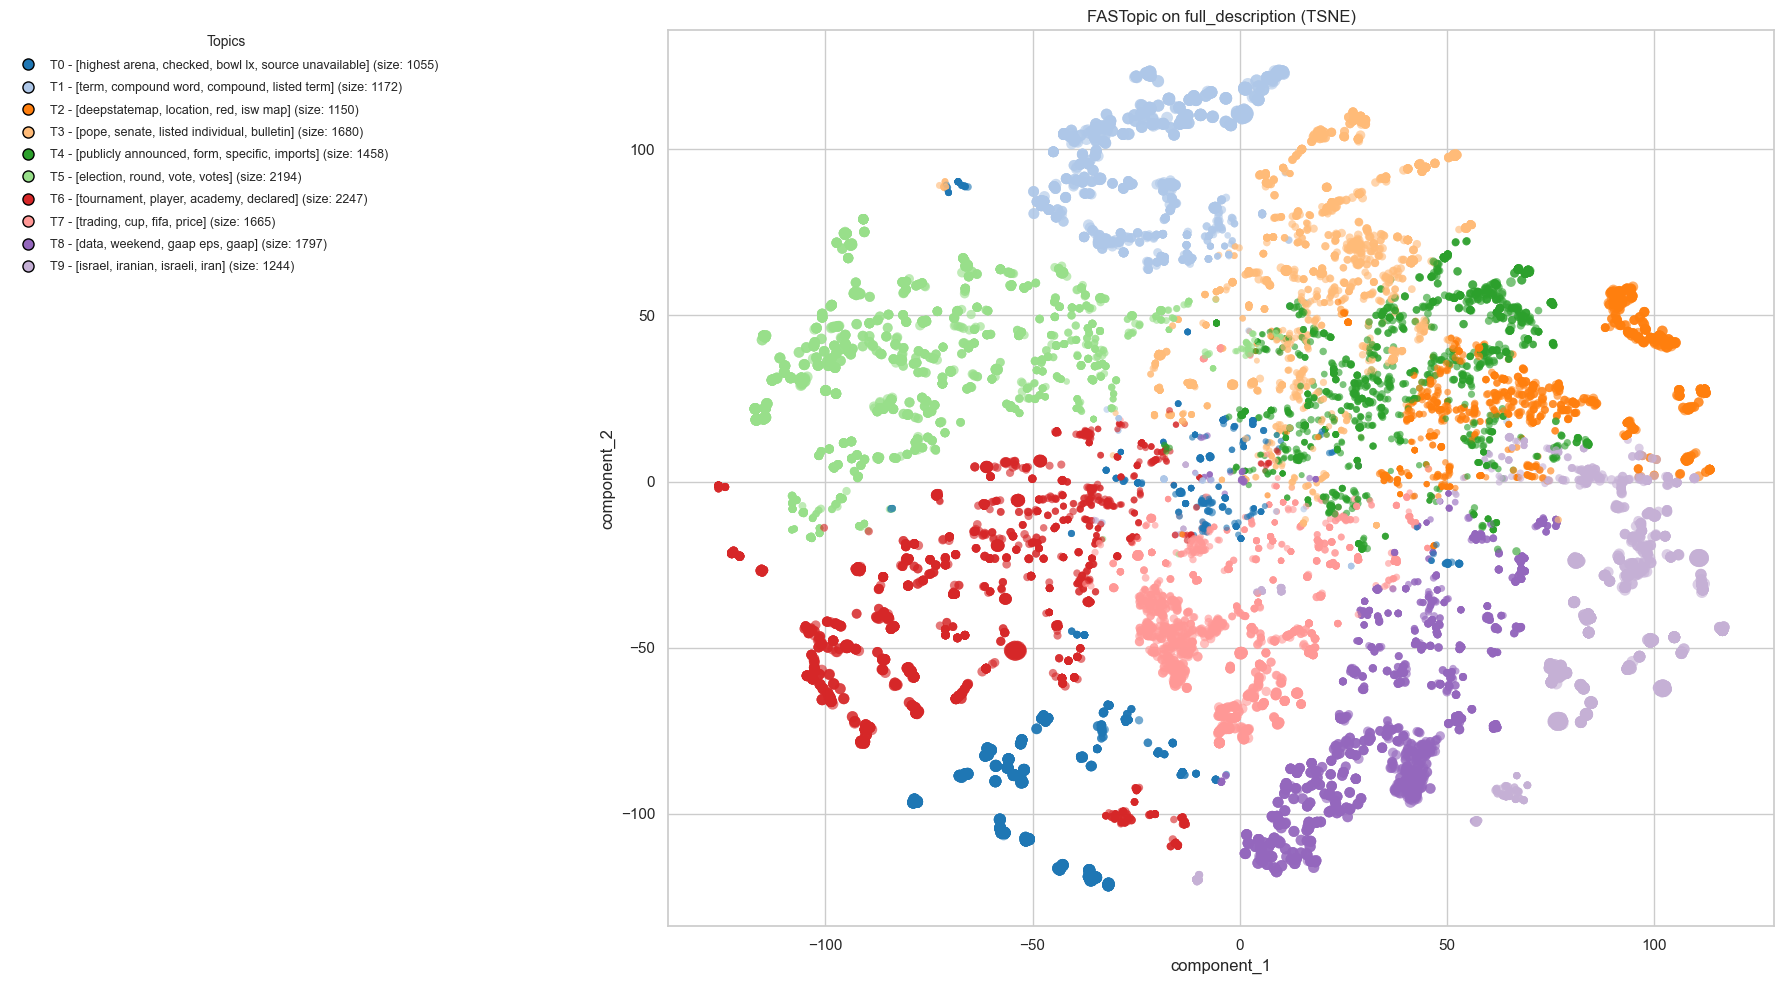

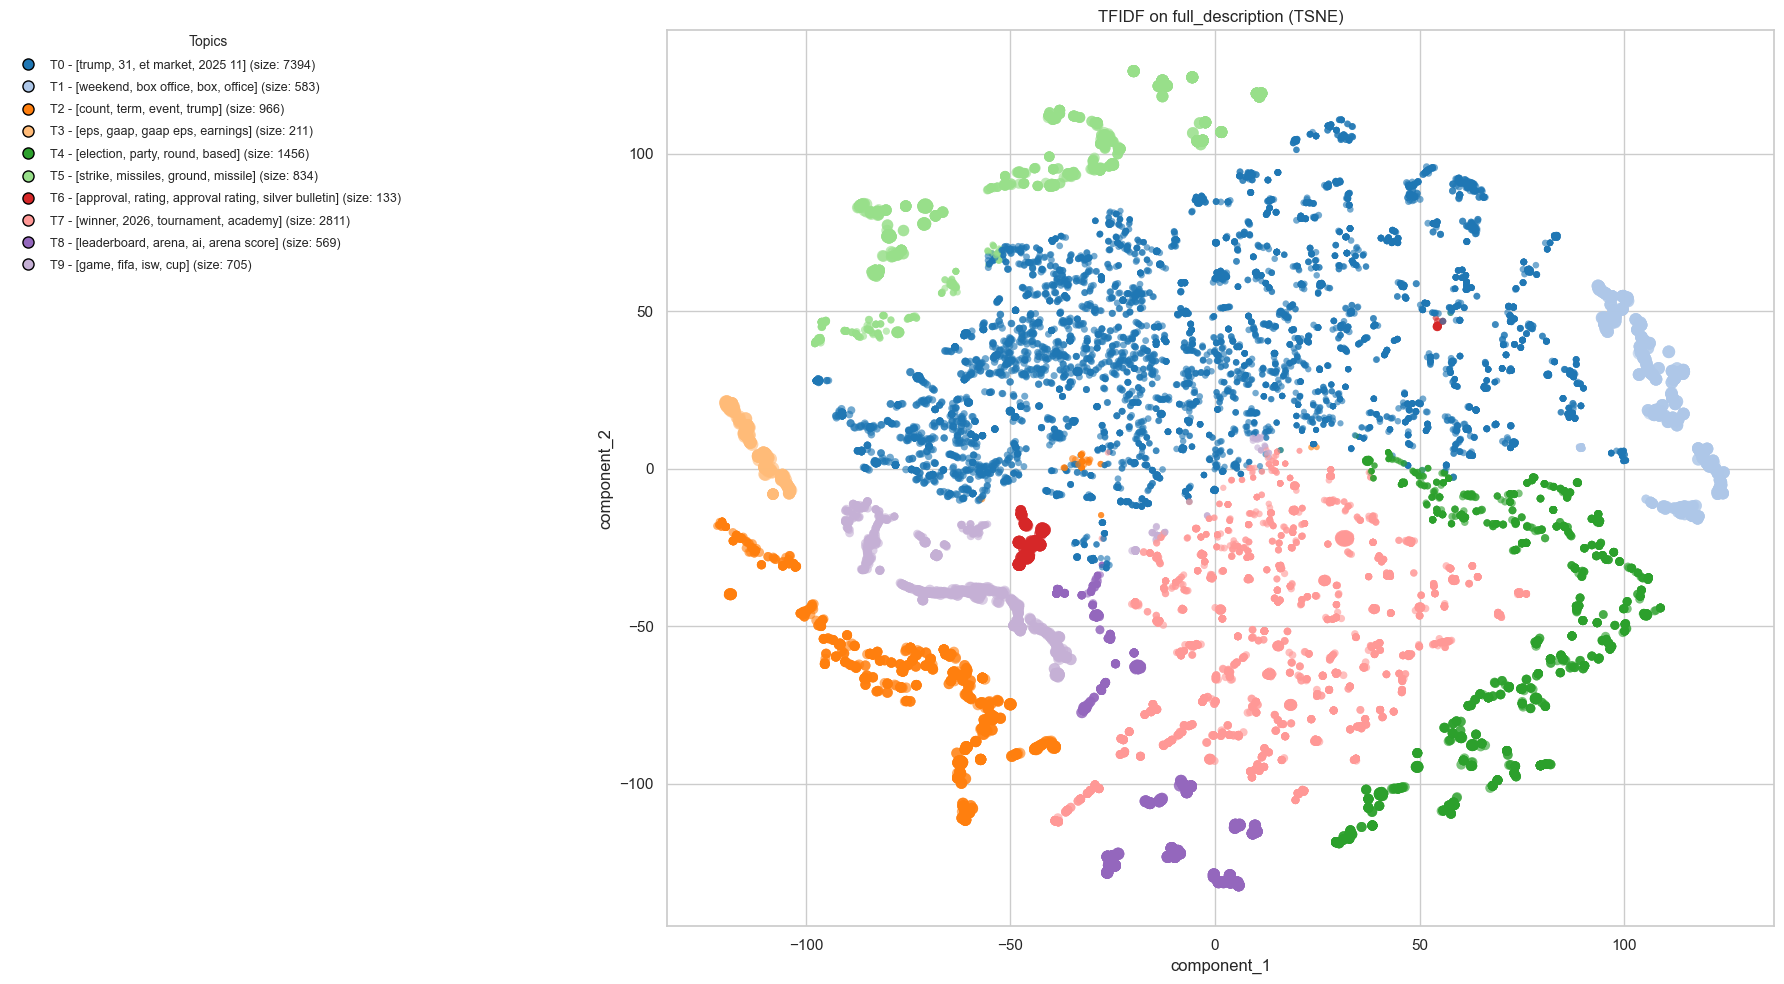

In [11]:
for model_name, result in results.items():
    fig, axes, projected = result.plot_2d_with_topic_map(
        reducer="tsne",
        random_state=0,
        legend_mode="full",
        show_table=False,
        figsize=(18, 10),
    )
    plt.show()

In [ ]:
TOP_DOCS_PER_TOPIC = 2
for model_name, result in results.items():
    print("=" * 100)
    print(f"Representative documents for {model_name}")
    display(
        result.representative_documents(top_n=TOP_DOCS_PER_TOPIC)[
            ["market_id", "topic_id", "topic_confidence", "topic_label", "question", "full_description"]
        ]
    )

Representative documents for S3


,market_id,topic_id,topic_confidence,topic_label,question,full_description
0,799386,0,1.000000,"topic_0: israel strikes, israel strike, strike gaza, strike lebanon",Will Anicet-Georges Dologuélé win the 2025 Central African Republic presidential election?,"Presidential elections are scheduled to be held in the Central African Republic on December 28, 2025. If no candidate secures more than 50% of the vote outright, a second round of elections will be scheduled. This market will resolve to the candidate who wins this election. Otherwise, this market will resolve to ""No"". This market includes any potential second round. If the result of this election isn't known by March 31, 2026, 11:59 PM ET, the market will resolve to ""Other"". This market will resolve based on the result of this election as indicated by a consensus of credible reporting. If there is ambiguity, this market will resolve based solely on the official results as reported by the Government of the Central African Republic, specifically the National Elections Authority (Autorité nationale des élections or ANE on https://www.ane-rca.org/). If the election outcome is ambiguous and the information from the specified resolution source is not definitive, this market will resolve to the candidate who takes office the following term. Central African Republic Presidential Election"
1,799385,0,1.000000,"topic_0: israel strikes, israel strike, strike gaza, strike lebanon",Will Faustin-Archange Touadéra win the 2025 Central African Republic presidential election?,"Presidential elections are scheduled to be held in the Central African Republic on December 28, 2025. If no candidate secures more than 50% of the vote outright, a second round of elections will be scheduled. This market will resolve to the candidate who wins this election. Otherwise, this market will resolve to ""No"". This market includes any potential second round. If the result of this election isn't known by March 31, 2026, 11:59 PM ET, the market will resolve to ""Other"". This market will resolve based on the result of this election as indicated by a consensus of credible reporting. If there is ambiguity, this market will resolve based solely on the official results as reported by the Government of the Central African Republic, specifically the National Elections Authority (Autorité nationale des élections or ANE on https://www.ane-rca.org/). If the election outcome is ambiguous and the information from the specified resolution source is not definitive, this market will resolve to the candidate who takes office the following term. Central African Republic Presidential Election"
2,640534,0,0.973632,"topic_0: israel strikes, israel strike, strike gaza, strike lebanon",Will Andorra win on 2025-11-13?,"In the upcoming game, scheduled for November 13, 2025 If Andorra wins, this market will resolve to ""Yes"". Otherwise, this market will resolve to ""No"". If the game is postponed, this market will remain open until the game has been completed. If the game is canceled entirely, with no make-up game, this market will resolve ""No"". This market refers only to the outcome within the first 90 minutes of regular play plus stoppage time. fifa.com Andorra vs. Albania"
3,1169204,0,0.928014,"topic_0: israel strikes, israel strike, strike gaza, strike lebanon",Iran Strike on Israel by January 31?,"This market will resolve to ""Yes"" if an Iran-initiated drone, missile, or air strike on the soil of Israel is announced or credibly reported to have occurred by the listed date, 11:59 PM ET. Otherwise, this market will resolve to ""No"". For the purposes of this market, a qualifying ""strike"" is defined as the use of aerial bombs, drones, or missiles (including FPV and ATGM strikes as well as cruise or ballistic missiles) launched by any Iranian operatives, including military forces, intelligence agencies, or other Iranian government operatives, that physically impact ground territory within the listed country. A strike on any

Representative documents for FASTopic


,market_id,topic_id,topic_confidence,topic_label,question,full_description
0,800482,0,0.483875,"topic_0: highest arena, checked, bowl lx, source unavailable",Will Google have the top AI model at the end of March 2026?,"This market will resolve according to the company that owns the model with the highest arena score based on the Chatbot Arena LLM Leaderboard when the table under the ""Leaderboard"" tab is checked on March 31, 2026, 12:00 PM ET. Results from the ""Arena Score"" section on the Leaderboard tab of https://lmarena.ai/leaderboard/text set to default (style control on) will be used to resolve this market. If two models are tied for the best arena score at this market's check time, resolution will be based on whichever company's name, as it is described in this market group, comes first in alphabetical order (e.g., if both were tied, ""Google"" would resolve to ""Yes"", and ""xAI"" would resolve to ""No"") The resolution source for this market is the Chatbot Arena LLM Leaderboard found at https://lmarena.ai/. If this resolution source is unavailable at check time, this market will remain open until the leaderboard comes back online and resolves based on the first check after it becomes available. If it becomes permanently unavailable, this market will resolve based on another resolution source. Which company has the top AI model end of March? (Style Control On)"
1,800483,0,0.483875,"topic_0: highest arena, checked, bowl lx, source unavailable",Will Anthropic have the top AI model at the end of March 2026?,"This market will resolve according to the company that owns the model with the highest arena score based on the Chatbot Arena LLM Leaderboard when the table under the ""Leaderboard"" tab is checked on March 31, 2026, 12:00 PM ET. Results from the ""Arena Score"" section on the Leaderboard tab of https://lmarena.ai/leaderboard/text set to default (style control on) will be used to resolve this market. If two models are tied for the best arena score at this market's check time, resolution will be based on whichever company's name, as it is described in this market group, comes first in alphabetical order (e.g., if both were tied, ""Google"" would resolve to ""Yes"", and ""xAI"" would resolve to ""No"") The resolution source for this market is the Chatbot Arena LLM Leaderboard found at https://lmarena.ai/. If this resolution source is unavailable at check time, this market will remain open until the leaderboard comes back online and resolves based on the first check after it becomes available. If it becomes permanently unavailable, this market will resolve based on another resolution source. Which company has the top AI model end of March? (Style Control On)"
2,800485,0,0.483875,"topic_0: highest arena, checked, bowl lx, source unavailable",Will Alibaba have the top AI model at the end of March 2026?,"This market will resolve according to the company that owns the model with the highest arena score based on the Chatbot Arena LLM Leaderboard when the table under the ""Leaderboard"" tab is checked on March 31, 2026, 12:00 PM ET. Results from the ""Arena Score"" section on the Leaderboard tab of https://lmarena.ai/leaderboard/text set to default (style control on) will be used to resolve this market. If two models are tied for the best arena score at this market's check time, resolution will be based on whichever company's name, as it is described in this market group, comes first in alphabetical order (e.g., if both were tied, ""Google"" would resolve to ""Yes"", and ""xAI"" would resolve to ""No"") The resolution source for this market is the Chatbot Arena LLM Leaderboard found at https://lmarena.ai/. If this resolution source is unavailable at check time, this market will remain open until the leaderboard comes back online and resolves based on the first check after it becomes available. If it becomes permanently unavailable, this market will resolve based on another resolution source. Which company has the top AI mode

Representative documents for TFIDF


,market_id,topic_id,topic_confidence,topic_label,question,full_description
0,542365,0,0.132565,"topic_0: trump, 31, et market, 2025 11","Trump renames Persian Gulf to ""Arabian Gulf"" in May?","This market will resolve to ""Yes"" if Donald Trump publicly announces, that the United States will officially refer to the Persian Gulf as the ""Arabian Gulf"" or ""Gulf of Arabia"" by May 31, 2025, 11:59 PM ET. Otherwise, this market will resolve to ""No"". The primary resolution source for this market will be official information from Donald Trump however, a consensus of credible reporting may also be used. Trump renames Persian Gulf to ""Arabian Gulf"" in May?"
1,567267,0,0.132322,"topic_0: trump, 31, et market, 2025 11",Trump revokes any US citizenship by December 31?,"This market will resolve to ""Yes"" if any full U.S. citizenship is officially rescinded by December 31, 2025, 11:59 PM ET. Otherwise, this market will resolve to ""No"". The primary resolution sources will be information from the government of the United States, however a consensus of credible reporting will also be used. Trump revokes any US citizenship by December 31?"
2,588751,0,0.131422,"topic_0: trump, 31, et market, 2025 11",Will Eric Adams join Trump administration by December 31?,"This market will resolve to ""Yes"" if Donald Trump officially nominates or appoints Eric Adams to his administration by December 31, 2025, 11:59 PM ET. Otherwise, this market will resolve to ""No"". The Trump administration includes individuals formally appointed or nominated by Donald Trump to roles within the U.S. federal government, such as Cabinet members, Executive Office staff, senior policy advisors, ambassadors, or White House staff whose appointments are publicly announced by official government channels. Nominations will qualify even if the individual is not confirmed. The primary resolution source for this market will be official information from the US government; however, a consensus of credible reporting may also be used. Will Eric Adams join Trump administration by December 31?"
3,549903,0,0.130416,"topic_0: trump, 31, et market, 2025 11",Will Elon Musk rejoin the Trump Administration this year?,"This market will resolve to ""Yes"" if Donald Trump officially nominates or appoints Elon Musk to his administration between June 4, and December 31, 2025, 11:59 PM ET. Otherwise, this market will resolve to ""No"". The Trump administration includes individuals formally appointed or nominated by Donald Trump to roles within the U.S. federal government, such as Cabinet members, Executive Office staff, senior policy advisors, ambassadors, or White House staff whose appointments are publicly announced by official government channels. Nominations will qualify even if the individual is not confirmed. The primary resolution source for this market will be official information from the US government, however a consensus of credible reporting may also be used. Will Elon Musk rejoin the Trump Administration this year?"
4,581246,0,0.129374,"topic_0: trump, 31, et market, 2025 11",Will Trump release more Epstein files in 2025?,"This market will resolve to ""Yes"" if the Trump Administration (including any federal court) publicly releases any files pertaining to the illegal activities of Jeffrey Epstein, which weren’t previously public between August 25 and December 31, 2025, 11:59 PM ET. Otherwise, this market will resolve to ""No"". Only files which were created prior to the start of the Trump Administration (January 20, 2025, 12:00 PM ET) will qualify. Announcements of declassifications or releases that are not implemented within this market's timeframe will not qualify. The primary resolution source for this market will be official information from the government of the United States, however a consensus of credible reporting will also be used. Will Trump release more Epstein files in 2025?"
5,600697,1,0.219677,"topic_1: weekend, box office, box, office","Will ""One Battle After Ano